# Pipeline de Modelado para Detección de Vishing
Este notebook entrena y evalúa múltiples algoritmos (Regresión Logística, Random Forest, XGBoost y Redes Neuronales) iterando sobre los diferentes datasets generados en el proceso de balanceo de datos (SMOTE, ENN, Oversampling, etc.).

## 1. Configuración y Extracción del Hold-out (Set de Prueba)
Para evaluar justamente, necesitamos un set de prueba totalmente virgen (sin balancear). Tomaremos el dataset original y extraeremos un 20% para evaluación.

In [4]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Cargar datos originales para obtener un Test Set realista
df_raw = pd.read_csv('raw_data/dataset_sintetico_biocatch_vishing.csv')

# Excluir features que causan data leakage según el EDA
cols_to_drop = ['session_id', 'customer_id', 'session_timestamp', 'biocatch_risk_score', 'biocatch_genuine_score', 
                'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'days_to_claim', 'claim_category','os_type','app_version','device_type']

for col in ['screens_visited', 'unusual_screen_visits']:
    if col in df_raw.columns:
        df_raw.drop(columns=[col], inplace=True)

df_raw = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])

X_orig = df_raw.drop(columns=['is_vishing'])
y_orig = df_raw['is_vishing']

_, X_test, _, y_test = train_test_split(X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig)

scaler = StandardScaler()

## 2. Definición del Pipeline Multimodelo
Iteraremos a través de cada carpeta y archivo dentro de data/.

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=6, learning_rate=0.1, random_state=42),
    'Deep Learning (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42)
}

data_paths = glob.glob('data/**/*.csv', recursive=True)
results = []

print(f"Detectados {len(data_paths)} datasets balanceados para evaluación.")

Detectados 12 datasets balanceados para evaluación.


In [22]:
for path in data_paths:
    technique = Path(path).parent.name
    ratio = Path(path).stem
    
    print(f"\n--- Evaluando {technique} al {ratio}% ---")
    
    df_train = pd.read_csv(path)
    df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], errors='ignore')
    
    for col in ['screens_visited', 'unusual_screen_visits']:
        if col in df_train.columns:
            df_train.drop(columns=[col], inplace=True)
            
    X_train = df_train.drop(columns=['is_vishing'])
    y_train = df_train['is_vishing']
    
    X_train = X_train[X_test.columns]
    
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for model_name, model in models.items():
        if model_name in ['Logistic Regression', 'Deep Learning (MLP)']:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test
            
        model.fit(X_tr, y_train)
        
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else y_pred
        
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        
        results.append({
            'Technique': technique,
            'Ratio_%': ratio,
            'Model': model_name,
            'Recall': recall,
            'Precision': precision,
            'F1': f1,
            'ROC_AUC': roc_auc,
            'PR_AUC': pr_auc
        })
        
print("\n¡Pipeline de iteración masiva finalizado exitosamente!")


--- Evaluando borderline_smote al 10% ---

--- Evaluando borderline_smote al 20% ---

--- Evaluando borderline_smote al 25% ---

--- Evaluando random_oversampling al 10% ---

--- Evaluando random_oversampling al 20% ---

--- Evaluando random_oversampling al 25% ---

--- Evaluando smote al 10% ---

--- Evaluando smote al 20% ---

--- Evaluando smote al 25% ---

--- Evaluando smote_undersampling al 10% ---

--- Evaluando smote_undersampling al 20% ---

--- Evaluando smote_undersampling al 25% ---

¡Pipeline de iteración masiva finalizado exitosamente!


## 3. Análisis de Resultados e Identificación de la Mejor Estrategia

In [23]:
df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(by='PR_AUC', ascending=False)
display(df_results_sorted.head(15).style.background_gradient(cmap='viridis', subset=['Recall', 'PR_AUC', 'ROC_AUC']))

,Technique,Ratio_%,Model,Recall,Precision,F1,ROC_AUC,PR_AUC
13,random_oversampling,10,Random Forest,0.010000,1.000000,0.019802,1.000000,1.000000
29,smote,20,Random Forest,0.002000,1.000000,0.003992,1.000000,1.000000
21,random_oversampling,25,Random Forest,0.104000,1.000000,0.188406,1.000000,1.000000
17,random_oversampling,20,Random Forest,0.018000,1.000000,0.035363,1.000000,1.000000
1,borderline_smote,10,Random Forest,0.000000,0.000000,0.000000,1.000000,0.999992
5,borderline_smote,20,Random Forest,0.002000,1.000000,0.003992,1.000000,0.999992
25,smote,10,Random Forest,0.002000,1.000000,0.003992,0.999999,0.999984
9,borderline_smote,25,Random Forest,0.008000,1.000000,0.015873,0.999999,0.999980
41,smote_undersampling,20,Random Forest,0.000000,0.000000,0.000000,0.999998,0.999964
37,smote_undersampling,10,Random Forest,0.000000,0.000000,0.000000,0.999994,0.999889


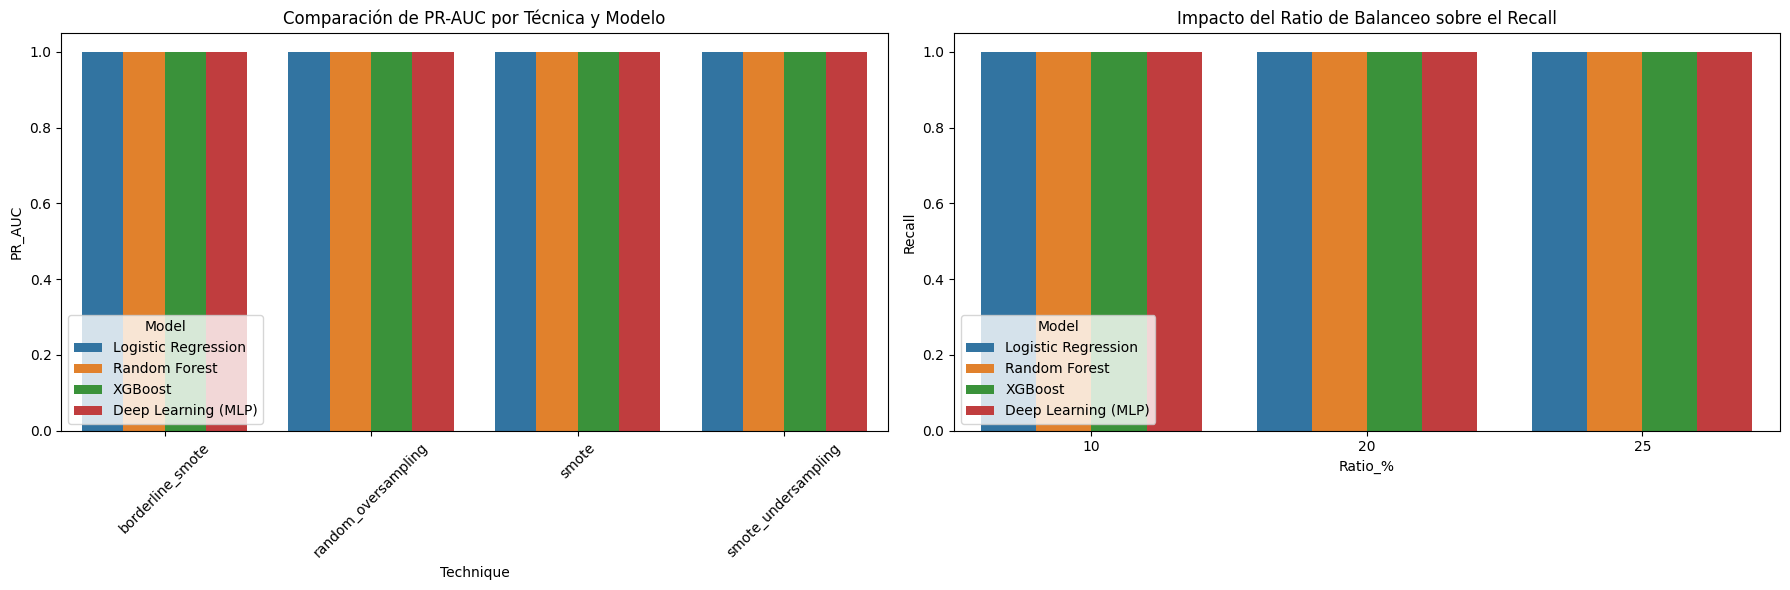

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_results, x='Technique', y='PR_AUC', hue='Model', ax=ax1)
ax1.set_title('Comparación de PR-AUC por Técnica y Modelo')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sns.barplot(data=df_results, x='Ratio_%', y='Recall', hue='Model', ax=ax2)
ax2.set_title('Impacto del Ratio de Balanceo sobre el Recall')

plt.tight_layout()
plt.show()

## 4. Matriz de Confusión — Mejor Modelo: XGBoost con SMOTE-Undersampling al 10%

Reentrenamos el modelo ganador sobre el dataset balanceado `smote_undersampling/10` y evaluamos sobre el hold-out set original para obtener una vista detallada de los errores (Falsos Negativos y Falsos Positivos).

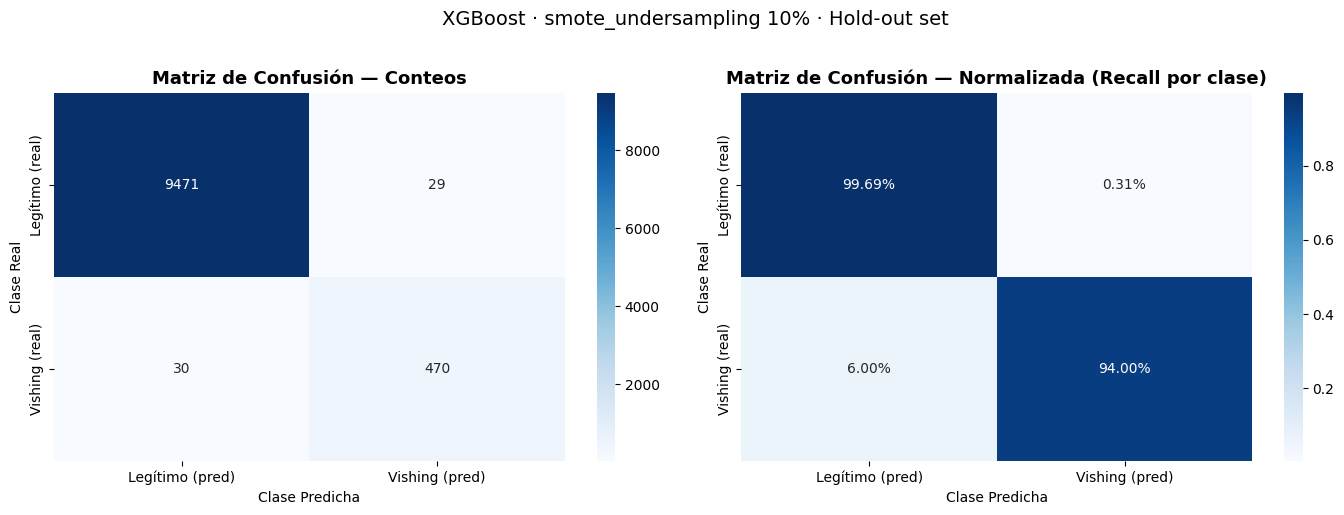


  Verdaderos Negativos (TN) :   9471  — Legítimos correctamente identificados
  Falsos Positivos     (FP) :     29  — Legítimos marcados como Vishing
  Falsos Negativos     (FN) :     30  — Vishing no detectados  ← riesgo crítico
  Verdaderos Positivos (TP) :    470  — Vishing correctamente detectados
  Recall    (Sensibilidad)  : 0.9400
  Precision                 : 0.9419
  F1-Score                  : 0.9409
  ROC-AUC                   : 0.9988
  PR-AUC                    : 0.9848


In [8]:
# --- Mejor modelo: XGBoost | smote_undersampling | 10% ---
best_path = 'data/smote_undersampling/10.csv'

df_best = pd.read_csv(best_path)
df_best = df_best.drop(columns=[c for c in cols_to_drop if c in df_best.columns], errors='ignore')
for col in ['screens_visited', 'unusual_screen_visits']:
    if col in df_best.columns:
        df_best.drop(columns=[col], inplace=True)

X_best = df_best.drop(columns=['is_vishing'])[X_test.columns]
y_best = df_best['is_vishing']

best_model = XGBClassifier(
    use_label_encoder=False, eval_metric='logloss',
    max_depth=6, learning_rate=0.1, random_state=42
)
best_model.fit(X_best, y_best)

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión con conteos
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Legítimo (pred)', 'Vishing (pred)'],
    yticklabels=['Legítimo (real)', 'Vishing (real)']
)
axes[0].set_title('Matriz de Confusión — Conteos', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

# Matriz de confusión normalizada (por fila = recall por clase)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
    xticklabels=['Legítimo (pred)', 'Vishing (pred)'],
    yticklabels=['Legítimo (real)', 'Vishing (real)']
)
axes[1].set_title('Matriz de Confusión — Normalizada (Recall por clase)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.suptitle('XGBoost · smote_undersampling 10% · Hold-out set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"  Verdaderos Negativos (TN) : {tn:>6}  — Legítimos correctamente identificados")
print(f"  Falsos Positivos     (FP) : {fp:>6}  — Legítimos marcados como Vishing")
print(f"  Falsos Negativos     (FN) : {fn:>6}  — Vishing no detectados  ← riesgo crítico")
print(f"  Verdaderos Positivos (TP) : {tp:>6}  — Vishing correctamente detectados")
print(f"{'='*50}")
print(f"  Recall    (Sensibilidad)  : {tp/(tp+fn):.4f}")
print(f"  Precision                 : {tp/(tp+fp):.4f}")
print(f"  F1-Score                  : {2*tp/(2*tp+fp+fn):.4f}")
print(f"  ROC-AUC                   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  PR-AUC                    : {average_precision_score(y_test, y_prob_best):.4f}")
print(f"{'='*50}")